<a href="https://colab.research.google.com/github/Kelly-Violet2/assignment2.ipynb/blob/main/assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1(e)

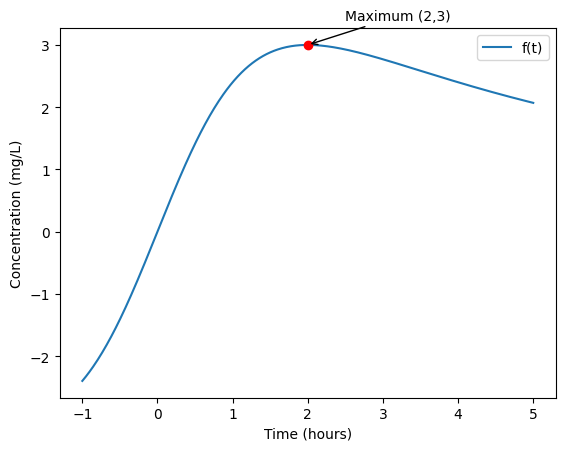

In [114]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

t = sp.symbols('t')
f = (12*t)/(t**2 + 4)

f_num = sp.lambdify(t, f, 'numpy')

x = np.linspace(-1, 5, 500)
y = f_num(x)

plt.plot(x, y, label='f(t)')

# maximum point
plt.plot(2, 3, 'ro')  # <-- THIS is your dot

plt.annotate('Maximum (2,3)', xy=(2,3), xytext=(2.5,3.4),
             arrowprops=dict(arrowstyle='->'))

plt.xlabel('Time (hours)')
plt.ylabel('Concentration (mg/L)')
plt.legend()

Q2(d)

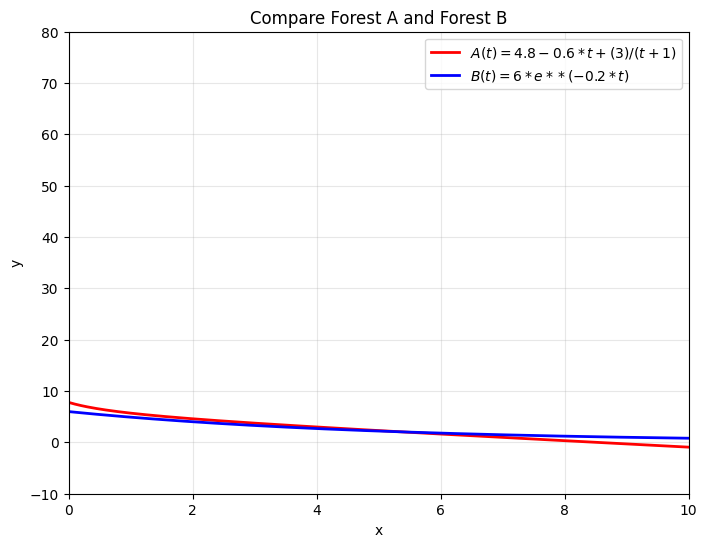

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from sympy import E as e

t = sp.symbols('t')

# Two curves: A'(t) = 4.8-0.6*t + (3)/(t+1) (A) and B'(t) = 6*e**(-0.2*t) (B)
A = 4.8-0.6*t + (3)/(t+1)
B = 6*e**(-0.2*t)

# Plotting
t_vals = np.linspace(0, 10, 200)
y_A = 4.8-0.6*t_vals + (3)/(t_vals+1)
y_B = 6*e**(-0.2*t_vals)

plt.figure(figsize=(8, 6))
plt.plot(t_vals, y_A, 'r-', linewidth=2, label=r'$A(t) = 4.8-0.6*t + (3)/(t+1)$')
plt.plot(t_vals, y_B, 'b-', linewidth=2, label=r'$B(t) = 6*e**(-0.2*t)$')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Compare Forest A and Forest B')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 10)
plt.ylim(-10, 80)
plt.show()

In [116]:
from scipy.integrate import quad
import numpy as np

# A'(t)
def A_prime(t):
    return 4.8 - 0.6*t + 3/(t+1)

# B'(t)
def B_prime(t):
    return 6 * np.exp(-0.2*t)

# Integrals from 0 to 10
A_result, A_error = quad(A_prime, 0, 10)
B_result, B_error = quad(B_prime, 0, 10)

print("Integral of A'(t):", A_result)
print("Integral of B'(t):", B_result)

Integral of A'(t): 25.193685818395203
Integral of B'(t): 25.939941502901615


Researcher claim is wrong, but only just. There is a slight difference in absorbed CO2 from the forests.

Q4(b)

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import sympy as sp

# Define parameters (exam-style values)
alpha = 1.0   # prey birth rate
beta = 0.02   # predation rate on prey
lambda_ = 0.01  # predator birth rate from feeding
gamma = 0.5   # predator death rate

# Store as tuple for passing to functions
params = (alpha, beta, lambda_, gamma)

# Calculate equilibrium points
H_star = gamma / lambda_
P_star = alpha / beta
print(f"Coexistence equilibrium: (H*, P*) = ({H_star}, {P_star})")

# Calculate predator efficiency
efficiency = lambda_ / beta
print(f"Predator efficiency: {efficiency} = {efficiency*100}%")

Coexistence equilibrium: (H*, P*) = (50.0, 50.0)
Predator efficiency: 0.5 = 50.0%


In [118]:
def lotka_volterra(populations, t, params):
    """
    Defines the Lotka-Volterra ODEs for odeint.

    Parameters:
    -----------
    populations : array-like
        Current state [H, P] (prey, predator)
    t : float
        Current time (not used, but required by odeint)
    params : tuple
        (alpha, beta, lambda_, gamma)

    Returns:
    --------
    list : [dH/dt, dP/dt]
    """
    H, P = populations
    alpha, beta, lambda_, gamma = params

    # Prey equation: dH/dt = αH - βHP
    dHdt = alpha * H - beta * H * P

    # Predator equation: dP/dt = λHP - γP
    dPdt = lambda_ * H * P - gamma * P

    return [dHdt, dPdt]

# Test at equilibrium (should return [0, 0])
test_result = lotka_volterra([200, 30], 0, params)
print(f"Derivatives at equilibrium: {test_result}")

# Test away from equilibrium
test_result2 = lotka_volterra([500, 10], 0, params)
print(f"Derivatives at (500, 10): dH/dt={test_result2[0]:.2f}, dP/dt={test_result2[1]:.2f}")

Derivatives at equilibrium: [80.0, 45.0]
Derivatives at (500, 10): dH/dt=400.00, dP/dt=45.00


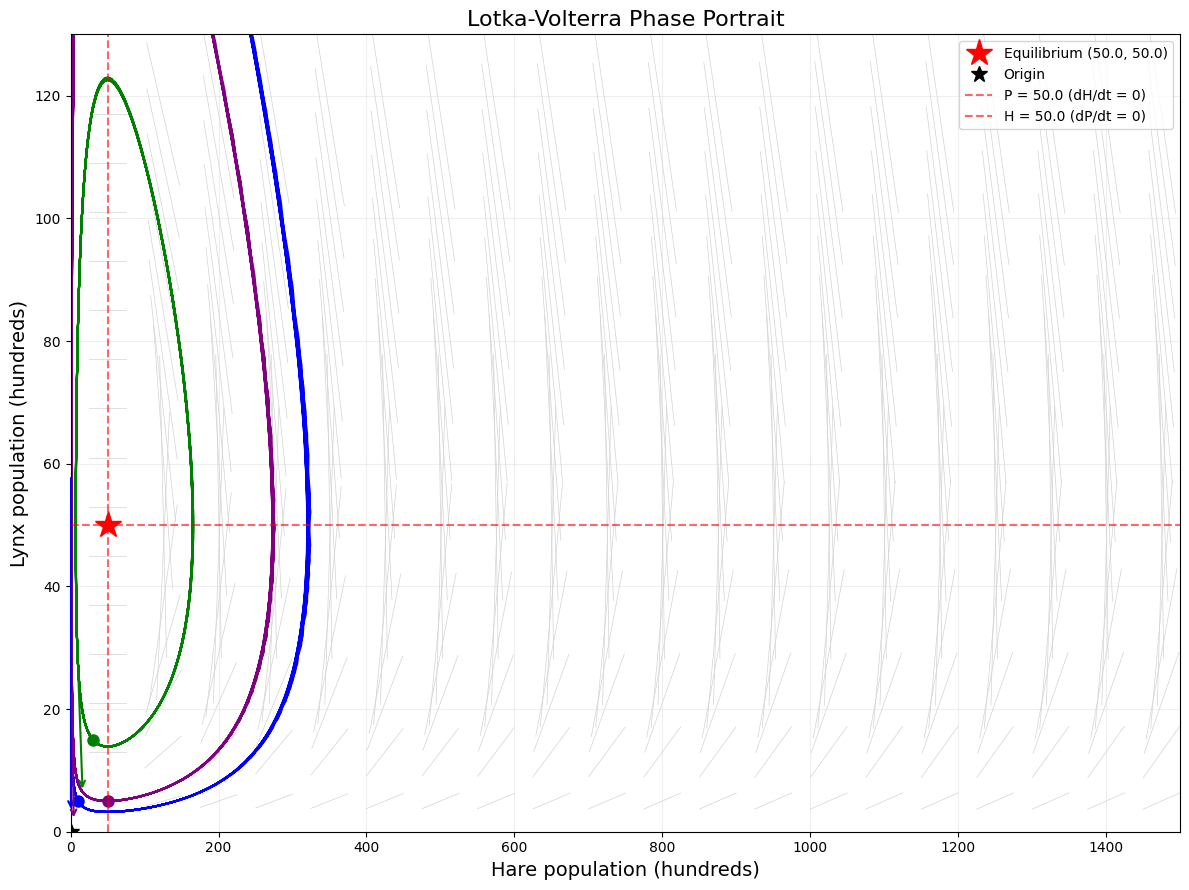

In [119]:
fig, ax = plt.subplots(figsize=(12, 9))

# 1. Draw vector field (light gray background)
H_range = np.arange(50, 1501, 75)
P_range = np.arange(5, 121, 8)
scale = 25

for H in H_range:
    for P in P_range:
        dHdt = alpha * H - beta * H * P
        dPdt = lambda_ * H * P - gamma * P
        magnitude = np.sqrt(dHdt**2 + dPdt**2)
        if magnitude > 0.01:
            dH_norm = dHdt / magnitude * scale
            dP_norm = dPdt / magnitude * scale
            ax.plot([H - dH_norm, H + dH_norm],
                    [P - dP_norm, P + dP_norm],
                    color='lightgray', linewidth=0.5)

# 2. Solve for multiple initial conditions
initial_conditions = [
    (10, 5, 'blue'),
    (30, 15, 'green'),
    (50, 5, 'purple')
]

t = np.linspace(0, 100, 500)

for H0, P0, color in initial_conditions:
    sol = odeint(lotka_volterra, [H0, P0], t, args=(params,))
    ax.plot(sol[:, 0], sol[:, 1], color=color, linewidth=1.5)
    ax.plot(H0, P0, 'o', color=color, markersize=8) # Start point

     # Add arrow at time index 40
    idx = 40
    dH = sol[idx+1, 0] - sol[idx, 0]
    dP = sol[idx+1, 1] - sol[idx, 1]
    ax.annotate('', xy=(sol[idx, 0] + 10*dH, sol[idx, 1] + 10*dP),
                xytext=(sol[idx, 0], sol[idx, 1]),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

# 3. Mark equilibria
ax.plot(H_star, P_star, 'r*', markersize=20, label=f'Equilibrium ({H_star}, {P_star})')
ax.plot(0, 0, 'k*', markersize=12, label='Origin')

# 4. Add nullclines
ax.axhline(y=P_star, color='red', linestyle='--', alpha=0.6, label=f'P = {P_star} (dH/dt = 0)')
ax.axvline(x=H_star, color='red', linestyle='--', alpha=0.6, label=f'H = {H_star} (dP/dt = 0)')

ax.set_xlabel('Hare population (hundreds)', fontsize=14)
ax.set_ylabel('Lynx population (hundreds)', fontsize=14)
ax.set_title('Lotka-Volterra Phase Portrait', fontsize=16)
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim(0, 1500)
ax.set_ylim(0, 130)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()